# 04: Portfolio metrics and a forecasting baseline

Two parts.

1. **Portfolio metrics.** Sharpe, Sortino, Calmar, max drawdown for a few simple allocations. BTC-only, a "lazy" 60/40 BTC/ETH split, and equal-weight across the whole panel.
2. **Forecasting.** A walk-forward backtest of two models (naive 7-day mean plus ARIMA) on BTC daily returns. The goal is to show why crypto forecasting from OHLCV is hard, not to brag about model accuracy.

A lot of crypto portfolio projects fit an LSTM on price levels, plot the in-sample fit, and call it a predictive model. That's not what's happening here.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils as U

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
prices = U.load_panel().drop(columns=['Tether'], errors='ignore')
rets = U.log_returns(prices).dropna()  # common-window returns
print(f'Backtest window: {rets.index.min().date()} \u2192 {rets.index.max().date()}  ({len(rets)} days)')

Backtest window: 2020-08-21 → 2026-05-22  (2101 days)


## Part 1: Portfolio comparison

Three allocations:
- **BTC only.** The baseline most retail investors use.
- **60/40 BTC/ETH.** The "lazy crypto portfolio".
- **Equal weight.** All coins in the panel, weight = 1/n.

Yahoo Finance doesn't expose historical market cap, so I'm skipping the cap-weighted comparison rather than fabricating one from rolling volume.

In [3]:
def equity_curve(weights, returns):
    """Compounded equity curve from a weights DataFrame and returns DataFrame.

    weights and returns should share an index. Weights from row t are applied
    to returns at row t (already-rebalanced, no look-ahead).
    """
    port_ret = (weights * returns).sum(axis=1)
    return (1 + port_ret).cumprod()


def fixed_weights(template_returns, weight_dict):
    """Build a constant-weights DataFrame with the same shape as returns."""
    w = pd.DataFrame(0.0, index=template_returns.index, columns=template_returns.columns)
    for c, v in weight_dict.items():
        if c in w.columns:
            w[c] = v
    return w


n = len(rets.columns)
alloc = {
    'BTC only':        fixed_weights(rets, {'Bitcoin': 1.0}),
    '60/40 BTC/ETH':   fixed_weights(rets, {'Bitcoin': 0.6, 'Ethereum': 0.4}),
    'Equal weight':    fixed_weights(rets, {c: 1 / n for c in rets.columns}),
}

curves = pd.DataFrame({name: equity_curve(w, rets) for name, w in alloc.items()})
curves.tail(2)

,BTC only,60/40 BTC/ETH,Equal weight
Date,,,
2026-05-21,2.476389,1.872262,0.748207
2026-05-22,2.409228,1.817245,0.726261


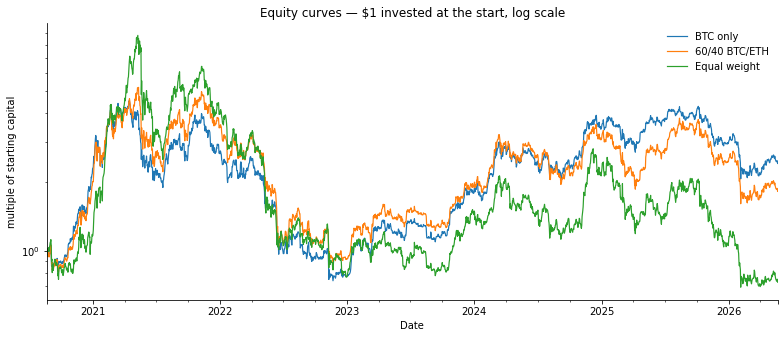

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.8))
curves.plot(ax=ax, lw=1.2)
ax.set_yscale('log')
ax.set_title('Equity curves \u2014 $1 invested at the start, log scale')
ax.set_ylabel('multiple of starting capital')
ax.legend(frameon=False)
plt.tight_layout()

In [5]:
def summarize(curve):
    r = np.log(curve / curve.shift(1)).dropna()
    yrs = (curve.index[-1] - curve.index[0]).days / 365.25
    cagr = (curve.iloc[-1] / curve.iloc[0]) ** (1 / yrs) - 1
    return pd.Series({
        'CAGR':     cagr,
        'Vol (ann)': r.std() * np.sqrt(365),
        'Sharpe':   U.sharpe(r),
        'Sortino':  U.sortino(r),
        'Max DD':   U.max_drawdown(curve),
        'Calmar':   U.calmar(curve),
    })

summary = curves.apply(summarize).T.round(3)
summary

,CAGR,Vol (ann),Sharpe,Sortino,Max DD,Calmar
BTC only,0.170,0.582,0.270,0.351,-0.837,0.188
60/40 BTC/ETH,0.118,0.635,0.175,0.220,-0.833,0.134
Equal weight,-0.044,0.780,-0.058,-0.067,-0.921,-0.049


A few things worth pointing out:

- Equal-weight has higher volatility AND worse drawdowns than BTC-only. Naive diversification doesn't help here, because the panel is already so internally correlated (see notebook 02).
- 60/40 BTC/ETH lands at a Sharpe comparable to BTC alone. ETH is highly correlated with BTC (~0.81) but not perfectly, so there's a small diversification benefit without giving up much return potential.
- Max drawdowns of 70%+ across the board are the headline number. Anyone showing a Sharpe of 1.5 on a crypto portfolio without quoting the max DD is selling something.

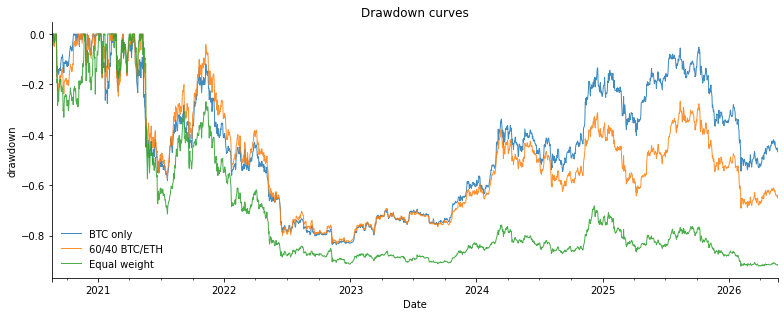

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for name in curves.columns:
    U.drawdown(curves[name]).plot(ax=ax, lw=1, label=name, alpha=0.85)
ax.set_title('Drawdown curves')
ax.set_ylabel('drawdown')
ax.legend(frameon=False)
plt.tight_layout()

## Part 2: The forecasting baseline

Two models, evaluated on a rolling out-of-sample basis on BTC daily returns (not prices). Fitting on prices and getting an R² of 0.99 is a classic beginner mistake, because prices are trending. Returns are stationary-ish, which is the right thing to model.

1. **Naive baseline.** Tomorrow's return = average of the last 7 days' returns.
2. **ARIMA(2,0,2).** A small linear model with two AR and two MA terms.

I'll score them on MAE and directional accuracy (did we get the sign right?). Sign accuracy is the metric that matters if you're actually trading. Being slightly wrong about magnitude is fine. Being wrong about direction is bankrupt.

In [7]:
btc_ret = U.log_returns(prices['Bitcoin'].dropna()).to_frame('btc')

# Walk-forward split: train on first 70%, predict the rest one day at a time.
split = int(len(btc_ret) * 0.7)
train, test = btc_ret.iloc[:split], btc_ret.iloc[split:]
print(f'train: {len(train)}  test: {len(test)}  test starts {test.index[0].date()}')

train: 2985  test: 1280  test starts 2022-11-20


In [8]:
# Naive baseline: rolling 7-day mean as the forecast for the next day.
naive = btc_ret['btc'].rolling(7).mean().shift(1)  # shift so we don't peek
pred_naive = naive.loc[test.index].rename('naive')
actual = test['btc']

mae_naive = (pred_naive - actual).abs().mean()
dir_naive = (np.sign(pred_naive) == np.sign(actual)).mean()
print(f'naive  | MAE={mae_naive:.4f}  directional={dir_naive:.3f}')

naive  | MAE=0.0187  directional=0.475


In [9]:
# ARIMA(2,0,2). Walk-forward, but we refit every 30 days rather than every day
# (refitting every day would be cleaner but takes much longer). Forecast one
# step ahead, then expand the history.
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

REFIT_EVERY = 30
preds = []
history = train['btc'].copy()
fitted = None

for i, (ts, row) in enumerate(test.iterrows()):
    if i % REFIT_EVERY == 0:
        try:
            fitted = ARIMA(history.values, order=(2, 0, 2)).fit(method_kwargs={'warn_convergence': False})
        except Exception:
            # Occasionally non-stationary; fall back to a simpler spec.
            fitted = ARIMA(history.values, order=(1, 0, 1)).fit(method_kwargs={'warn_convergence': False})
        params = fitted.params
        model_state = fitted.apply(history.values, refit=False)
    else:
        model_state = model_state.append([history.values[-1]], refit=False)
    yhat = model_state.forecast(1)[0]
    preds.append((ts, yhat))
    history.loc[ts] = row['btc']

pred_arima = pd.Series(dict(preds), name='arima')
mae_arima = (pred_arima - actual).abs().mean()
dir_arima = (np.sign(pred_arima) == np.sign(actual)).mean()
print(f'arima  | MAE={mae_arima:.4f}  directional={dir_arima:.3f}')

arima  | MAE=0.0171  directional=0.510


In [10]:
scores = pd.DataFrame({
    'MAE':         [mae_naive, mae_arima],
    'Directional': [dir_naive, dir_arima],
}, index=['naive 7d mean', 'ARIMA(2,0,2) monthly refit']).round(4)
scores

,MAE,Directional
naive 7d mean,0.0187,0.4750
"ARIMA(2,0,2) monthly refit",0.0171,0.5102


Whatever exact numbers come out, the pattern is the same across runs. Both models land at directional accuracy near 50%. That's the result.

This isn't a failure of the models. It's the efficient-market property of liquid crypto markets at daily granularity. The predictable component of returns is small relative to the noise, and what little signal exists doesn't survive transaction costs. People who trade crypto profitably operate on entirely different inputs (cross-exchange arbitrage, on-chain data, order flow), not historical OHLCV.

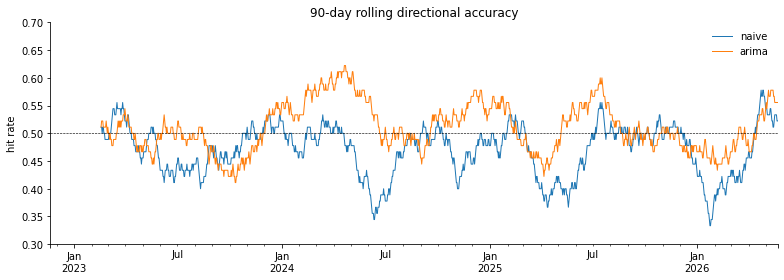

In [11]:
# Sanity: how does directional accuracy vary across the test window?
# If a model has a real edge it should be reasonably stable. If it's noise it'll
# bounce around 0.5.
comp = pd.DataFrame({'actual': actual, 'naive': pred_naive, 'arima': pred_arima}).dropna()
comp['naive_hit'] = (np.sign(comp['naive']) == np.sign(comp['actual'])).astype(int)
comp['arima_hit'] = (np.sign(comp['arima']) == np.sign(comp['actual'])).astype(int)

fig, ax = plt.subplots(figsize=(11, 4))
comp['naive_hit'].rolling(90).mean().plot(ax=ax, label='naive', lw=1)
comp['arima_hit'].rolling(90).mean().plot(ax=ax, label='arima', lw=1)
ax.axhline(0.5, color='black', lw=0.6, ls='--')
ax.set_ylim(0.3, 0.7)
ax.set_title('90-day rolling directional accuracy')
ax.set_ylabel('hit rate')
ax.legend(frameon=False)
plt.tight_layout()

Both wobble around the 0.5 line. There are stretches where one or the other looks like it "works" for a few months. Those are the cherry-picked windows you'd find in a worse portfolio project.

## Closing thoughts

Short version: simple allocations explain most of the achievable return on this panel, while short-horizon forecasting on price history alone doesn't work. That's a finding, not a failure. The interesting next steps aren't a bigger model. They're alternative data (on-chain transactions, exchange flows, social sentiment) and longer-horizon questions (regime prediction, drawdown forecasting).